# Day 1 Demo — Notebook 1 of 3: Embeddings & Vector Search Fundamentals

Covers cosine similarity, the `FlatIndex` brute-force baseline, and benchmarking
faiss (IVF-Flat) and hnswlib (HNSW) against it — build and search kept as
separate, timed steps for each method — plus recall@k trade-offs at different
search-time settings (`nprobe`, `ef`).

Runs entirely on the 10-category, 120-record varied dataset (deliberate overlap
between Billing/Finance_Reports and Orders/Inventory) — the same dataset used
in notebooks 2 and 3.

**Reference recall numbers from a full rehearsal run** (yours will vary slightly):

| Setting | IVF-Flat recall@5 | HNSW recall@5 |
|---|---|---|
| LOW (nprobe=1, ef=10) | 0.640 | 1.000 |
| HIGH (nprobe=8, ef=100) | 1.000 | 1.000 |

Build/search times will be small at this dataset size (120 records) — run the
Timing section once before your session to have your own real numbers ready,
rather than quoting these placeholders live.

## Setup (Colab)

FAISS (Facebook AI Similarity Search) is an open-source library developed by Meta for efficient similarity search and clustering of dense vectors. It is designed to handle datasets ranging from a few million to over a billion high-dimensional vectors, making it a backbone for modern recommendation systems, search engines and AI applications. Reference - https://www.geeksforgeeks.org/data-science/what-is-faiss/

In [ ]:
#%pip install -q sentence-transformers faiss-cpu hnswlib

## Embeddings, cosine similarity & the FlatIndex baseline

**all-MiniLM-L6-v2**
This is a sentence-transformers model: It maps sentences & paragraphs to a 384 dimensional dense vector space and can be used for tasks like clustering or semantic search.

**Cosine similarity**
measures the similarity between two non-zero vectors by calculating the cosine of the angle between them. It is widely used in machine learning and data analysis, especially in text analysis, document comparison, search queries, and recommendation systems.

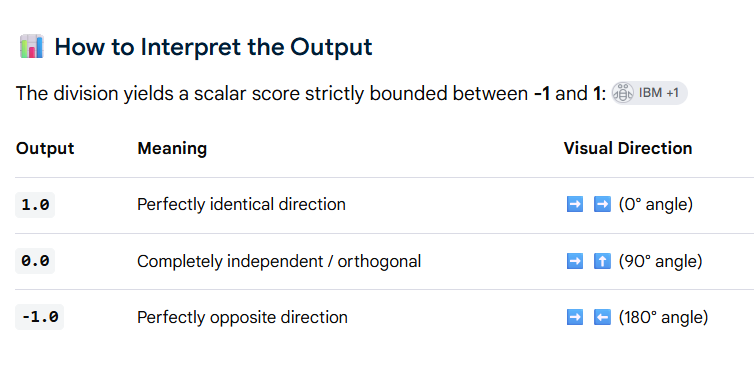

**FlatIndex** is the simplest possible way to find similar records — it checks every single one and ranks them. No shortcuts, no tricks. It's our baseline: the 'correct' answer that faiss and hnswlib are approximating faster. Every sentence gets converted into a list of numbers — an embedding — that captures its meaning. To find what's similar to a question, FlatIndex measures how close the question's numbers are to every single record's numbers, one by one, and returns the closest matches. It's exactly like comparing a new photo against every photo in an album to find the most similar one — accurate, but it gets slower as the album grows. That's the whole motivation for IVF-Flat and HNSW later: same idea, but smarter about which records they bother checking.



Ad: (*confused:FlatIndex measures how close the question's numbers are to every single record's numbers)

In [1]:
import numpy as np
import time
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

class FlatIndex:
    def __init__(self):
        self.vectors = None
        self.texts = None

    def build(self, embeddings, texts):
        self.vectors = embeddings
        self.texts = texts

    def search(self, query_embedding, top_k=3):
        sims = []
        for i in range(len(self.vectors)):
            sim = cosine_similarity(query_embedding, self.vectors[i])
            sims.append((i, sim, self.texts[i]))
        sims_sorted = sorted(sims, key=lambda x: x[1], reverse=True)
        return sims_sorted[:top_k]

c:\Users\jb842210\OneDrive - GSK\Documents\OntologyRagProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OSError: We couldn't connect to 'https://huggingface.co' to load the files, and couldn't find them in the cached files.
Check your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.

## The dataset (10 categories, deliberate overlap)

120 hand-written, non-templated, zero-duplicate sentences across 10 categories, some deliberately overlapping in meaning (Billing <-> Finance_Reports; Orders <-> Inventory) to genuinely stress-test clustering. This is the same dataset used in notebooks 2 and 3.

In [ ]:
categories = {
    "Orders": [
        "Customer placed an order for laptops",
        "Client purchased new office chairs",
        "The account holder bought a batch of monitors",
        "Purchase order submitted for networking equipment",
        "New order received for printer cartridges",
        "Bulk order placed for server racks",
        "Customer requested a quote before ordering keyboards",
        "Order confirmation sent for the tablet shipment",
        "Client re-ordered the same set of webcams",
        "Purchase request approved for docking stations",
        "Customer added routers to their existing order",
        "Order placed for annual software licenses",
    ],
    "Billing": [
        "Invoice payment overdue by 45 days",
        "Billing statement shows a late payment fee",
        "Customer disputed a charge on their invoice",
        "Monthly billing cycle closed with no discrepancies",
        "Client requested a copy of their last invoice",
        "Payment reminder sent for outstanding balance",
        "Invoice was issued with an incorrect tax amount",
        "Customer set up autopay for future invoices",
        "Billing department flagged a duplicate charge",
        "Credit note issued against a cancelled invoice",
        "Client's payment bounced and needs reprocessing",
        "Invoice reconciliation completed for the quarter",
    ],
    "Shipping": [
        "Order shipped to customer's warehouse yesterday",
        "Product delivered to client's facility on time",
        "Shipment delayed due to a courier issue",
        "Package was returned to sender as undeliverable",
        "Tracking number issued for the outbound shipment",
        "Customer requested expedited delivery for their order",
        "Freight carrier confirmed pickup for the pallet",
        "Delivery attempted but no one was available",
        "Shipment split into two boxes due to weight limits",
        "Client's order arrived damaged in transit",
        "Logistics team rerouted the shipment through a new hub",
        "Customs held the international shipment for inspection",
    ],
    "Complaints": [
        "Customer support ticket opened for a defective laptop",
        "New complaint raised about a broken monitor",
        "Client reported the product stopped working after a week",
        "Support agent escalated the complaint to engineering",
        "Customer requested a replacement for the faulty unit",
        "Complaint closed after the refund was processed",
        "Client unhappy with the quality of the delivered item",
        "Support ticket reopened after the same issue recurred",
        "Customer threatened to cancel their contract over service quality",
        "Negative feedback submitted about installation support",
        "Client escalated their complaint to a account manager",
        "Repeated complaints logged about the same product line",
    ],
    "Contracts_Legal": [
        "Legal team reviewed the vendor contract renewal",
        "New service agreement signed with the client",
        "Contract clause disputed during the negotiation",
        "Non-disclosure agreement executed before the meeting",
        "Vendor contract terminated due to non-performance",
        "Legal flagged a liability clause in the draft agreement",
        "Master service agreement amended to include new terms",
        "Client requested an extension on the contract deadline",
        "Procurement finalized the terms of the supplier contract",
        "Contract renewal pending legal department sign-off",
        "Breach of contract notice sent to the vendor",
        "Service level agreement updated with new penalties",
    ],
    "HR_Payroll": [
        "Payroll processed for all employees this month",
        "New hire onboarding completed for the engineering team",
        "Employee submitted a request for annual leave",
        "HR flagged a discrepancy in the timesheet submission",
        "Performance review scheduled for next quarter",
        "Employee benefits enrollment window opened today",
        "Exit interview conducted for a departing team member",
        "Payroll correction issued for a missed overtime payment",
        "HR approved the internal transfer request",
        "New employee handbook distributed to all staff",
        "Recruitment team shortlisted candidates for the open role",
        "Employee raised a grievance about scheduling conflicts",
    ],
    "IT_Security": [
        "Security team detected unusual login activity",
        "IT support resolved a network outage in the office",
        "Password reset requested for a locked user account",
        "Firewall rules updated after the security audit",
        "Phishing attempt reported by an employee",
        "IT deployed a patch for the recent vulnerability",
        "Server downtime scheduled for maintenance overnight",
        "Access request approved for the new database",
        "Data backup completed successfully for all systems",
        "Security incident triggered an automatic account lockout",
        "IT ticket raised for a malfunctioning laptop",
        "VPN access restored after the configuration fix",
    ],
    "Sales_Leads": [
        "Sales rep followed up with a qualified lead",
        "New lead captured through the website contact form",
        "Prospect requested a product demo next week",
        "Sales pipeline updated with three new opportunities",
        "Lead converted into a paying customer",
        "Cold outreach campaign generated several new leads",
        "Sales team lost a deal to a competitor",
        "Discovery call scheduled with a potential enterprise client",
        "Lead marked as unqualified after initial screening",
        "Proposal sent to a prospect following their demo",
        "Sales forecast updated based on pipeline movement",
        "Referral lead came in from an existing customer",
    ],
    "Inventory": [
        "Warehouse stock count completed for the quarter",
        "Inventory levels low for a key product line",
        "Stock replenishment order triggered automatically",
        "Warehouse team flagged a discrepancy in stock records",
        "New shipment received and added to inventory",
        "Obsolete stock marked for clearance sale",
        "Inventory audit found several missing units",
        "Stock transferred between two regional warehouses",
        "Reorder point reached for the printer cartridge SKU",
        "Damaged inventory written off during the audit",
        "Warehouse capacity nearing its storage limit",
        "Cycle count scheduled for the electronics section",
    ],
    "Finance_Reports": [
        "Quarterly revenue report prepared for the board",
        "Finance team closed the books for the fiscal year",
        "Budget variance analysis completed for the department",
        "Expense report submitted for the recent business trip",
        "Finance flagged an unexpected increase in operating costs",
        "Annual financial statements sent for external audit",
        "Cash flow forecast updated for the next two quarters",
        "Cost center allocation reviewed by the finance team",
        "Profit margin analysis shared with senior leadership",
        "Finance approved the capital expenditure request",
        "Revenue recognition policy updated per new guidelines",
        "Departmental spending reconciled against the annual budget",
    ],
}

varied_texts = []
varied_labels = []
for category, sentences in categories.items():
    for s in sentences:
        varied_texts.append(s)
        varied_labels.append(category)

print(f"Total records: {len(varied_texts)}")
print(f"Categories: {len(categories)}")
print(f"Unique sentences: {len(set(varied_texts))}")

varied_embeddings = model.encode(varied_texts, show_progress_bar=True)
print("Shape:", varied_embeddings.shape)

### Step 1 — benchmark FlatIndex on the dataset

In [ ]:
flat_index = FlatIndex()
flat_index.build(varied_embeddings, varied_texts)

query_text = "A customer's shipment was delayed by the courier"
query_embedding = model.encode([query_text])[0]

start = time.perf_counter()
flat_results = flat_index.search(query_embedding, top_k=5)
flat_time = time.perf_counter() - start
print(f"\nFlatIndex search took {flat_time*1000:.4f} ms")
for idx, score, text in flat_results:
    print(f"  sim={score:.4f}  {text}")

### Step 2 — build faiss IVF-Flat and benchmark

In [ ]:
import faiss

dim = varied_embeddings.shape[1]
print("Dimensions : ", dim)
nlist = 8  # number of clusters — 120 records, so keep this small

vectors_f32 = np.ascontiguousarray(varied_embeddings.astype('float32'))

quantizer = faiss.IndexFlatL2(dim) #Quantizer defines the centroids of each cluster
ivf_index = faiss.IndexIVFFlat(quantizer, dim, nlist)
ivf_index.train(vectors_f32)
ivf_index.add(vectors_f32)

query_f32 = np.ascontiguousarray(query_embedding.astype('float32').reshape(1, -1))

start = time.perf_counter()
distances, indices = ivf_index.search(query_f32, k=5) #Get 5 closest matches
ivf_time = time.perf_counter() - start
print(f"\nIVF-Flat search took {ivf_time*1000:.4f} ms")
for idx, dist in zip(indices[0], distances[0]):
    print(f"  dist={dist:.4f}  {varied_texts[idx]}")

### Step 3 — build HNSW and benchmark

In [ ]:
import hnswlib

hnsw_index = hnswlib.Index(space='cosine', dim=dim)
hnsw_index.init_index(max_elements=len(varied_texts), ef_construction=200, M=16)
hnsw_index.add_items(vectors_f32, np.arange(len(varied_texts)))
hnsw_index.set_ef(50)

start = time.perf_counter()
labels, distances = hnsw_index.knn_query(query_f32, k=5)
hnsw_time = time.perf_counter() - start
print(f"\nHNSW search took {hnsw_time*1000:.4f} ms")
for idx, dist in zip(labels[0], distances[0]):
    print(f"  dist={dist:.4f}  {varied_texts[idx]}")

## Timing: build vs. search, separately

Rebuilds IVF-Flat and HNSW from scratch so build cost and search cost are each measured cleanly, isolated from the combined build+search flow above.

In [ ]:
quantizer = faiss.IndexFlatL2(dim)
ivf_index_timed = faiss.IndexIVFFlat(quantizer, dim, nlist)

start = time.perf_counter()
ivf_index_timed.train(vectors_f32)
ivf_index_timed.add(vectors_f32)
ivf_build_time = time.perf_counter() - start
print(f"IVF-Flat BUILD took {ivf_build_time*1000:.4f} ms")

start = time.perf_counter()
distances, indices = ivf_index_timed.search(query_f32, k=5)
ivf_search_time = time.perf_counter() - start
print(f"IVF-Flat SEARCH took {ivf_search_time*1000:.4f} ms")

hnsw_index_timed = hnswlib.Index(space='cosine', dim=dim)
hnsw_index_timed.init_index(max_elements=len(varied_texts), ef_construction=200, M=16)

start = time.perf_counter()
hnsw_index_timed.add_items(vectors_f32, np.arange(len(varied_texts)))
hnsw_build_time = time.perf_counter() - start
print(f"\nHNSW BUILD took {hnsw_build_time*1000:.4f} ms")

hnsw_index_timed.set_ef(50)
start = time.perf_counter()
labels, distances = hnsw_index_timed.knn_query(query_f32, k=5)
hnsw_search_time = time.perf_counter() - start
print(f"HNSW SEARCH took {hnsw_search_time*1000:.4f} ms")

## Recall@k measurement

Measures how much accuracy IVF-Flat/HNSW give up at LOW vs. HIGH search-time settings (`nprobe`, `ef`), reusing the `ivf_index`/`hnsw_index` built in Steps 2/3 above.

IVF-Flat and nprobe — the "which drawers do I check" idea:

"**IVF-Flat first sorts all the records into clusters** — imagine the photo album split into labeled drawers: 'orders,' 'billing,' 'complaints,' roughly. When a new question comes in, it doesn't open every drawer — it only opens the nprobe closest-looking drawers and searches within those.

nprobe = 1 → open only the single most likely drawer. Fast, but if the answer was actually sitting in the second-most-likely drawer, you miss it entirely.
nprobe = 10 → open the 10 closest drawers. Slower, but much less likely to miss anything.

nprobe is a dial: turn it down for speed, turn it up for accuracy."

"**HNSW doesn't use drawers** — it builds a web of connections between records, like a social network. To search, it starts somewhere and hops to neighbors, then their neighbors, following the most promising direction. ef controls how many candidates it's allowed to keep exploring before it stops and gives you an answer.

Low ef → stop exploring early. Fast, but might settle on a good-enough neighbor instead of the actual best one.
High ef → keep exploring longer. Slower, but more likely to find the true best matches."

**So both nprobe and ef are the same trade-off wearing different clothes: how much effort am I willing to spend searching, versus how sure am I that I found the right answer?**

Recall@k answers exactly that: 'Out of the top-k results that FlatIndex — our always-correct baseline — says are the true best matches, how many did IVF-Flat or HNSW actually find?' A recall@5 of 0.640 means: out of the 5 truly closest records, this approximate method only found about 3 of them on average.

In [ ]:
import random as rnd

def recall_at_k(approx_indices, true_indices, k=5):
    true_set = set(true_indices[:k])
    approx_set = set(approx_indices[:k])
    return len(true_set & approx_set) / k

rnd.seed(11)
test_queries = rnd.sample(varied_texts, 20)

def get_flat_ground_truth(query_emb, k=5):
    results = flat_index.search(query_emb, top_k=k)
    return [r[0] for r in results]

def get_ivf_indices(query_emb, nprobe, k=5):
    ivf_index.nprobe = nprobe
    q = np.ascontiguousarray(query_emb.astype('float32').reshape(1, -1))
    _, indices = ivf_index.search(q, k=k)
    return indices[0].tolist()

def get_hnsw_indices(query_emb, ef, k=5):
    hnsw_index.set_ef(ef)
    q = np.ascontiguousarray(query_emb.astype('float32').reshape(1, -1))
    labels, _ = hnsw_index.knn_query(q, k=k)
    return labels[0].tolist()

for label, nprobe, ef in [("LOW (nprobe=1, ef=1)", 1, 1),
                            ("HIGH (nprobe=8, ef=100)", 8, 100)]:
    ivf_recalls = []
    hnsw_recalls = []
    for qtext in test_queries:
        q_emb = model.encode([qtext])[0]
        true_idx = get_flat_ground_truth(q_emb, k=5)
        ivf_idx = get_ivf_indices(q_emb, nprobe=nprobe, k=5)
        hnsw_idx = get_hnsw_indices(q_emb, ef=ef, k=5)
        ivf_recalls.append(recall_at_k(ivf_idx, true_idx, k=5))
        hnsw_recalls.append(recall_at_k(hnsw_idx, true_idx, k=5))
    print(f"\n{label}")
    print(f"  IVF-Flat  avg recall@5: {np.mean(ivf_recalls):.3f}")
    print(f"  HNSW      avg recall@5: {np.mean(hnsw_recalls):.3f}")

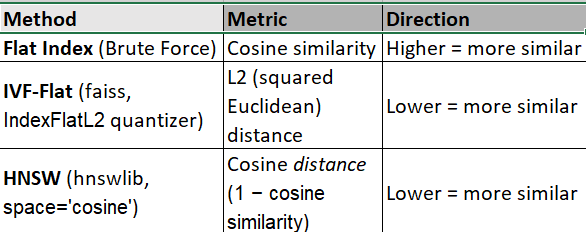

---
## Wrap-up

On this dataset, IVF-Flat clearly traded accuracy for speed at low `nprobe` and recovered it at high `nprobe` (0.640 -> 1.000) — the intuitive story. HNSW stayed at perfect recall in both settings here, which is also a fair thing to show: the dial doesn't always matter, depending on how cleanly separated the data already is. The one constant across every method: none of them change *what counts as similar* — only how fast/exhaustively you search a fixed, continuous notion of similarity. That's the setup for notebook 2, where similarity-based retrieval feeds an LLM and things go wrong in a new way.

In [ ]:
import random as rnd

def recall_at_k(approx_indices, true_indices, k=5):
    true_set = set(true_indices[:k])
    approx_set = set(approx_indices[:k])
    return len(true_set & approx_set) / k

rnd.seed(11)
test_queries = rnd.sample(varied_texts, 20)

def get_flat_ground_truth(query_emb, k=5):
    results = flat_index.search(query_emb, top_k=k)
    return [r[0] for r in results]

def get_ivf_indices(query_emb, nprobe, k=5):
    ivf_index.nprobe = nprobe
    q = np.ascontiguousarray(query_emb.astype('float32').reshape(1, -1))
    _, indices = ivf_index.search(q, k=k)
    return indices[0].tolist()

def get_hnsw_indices(query_emb, ef, k=5):
    hnsw_index.set_ef(ef)
    q = np.ascontiguousarray(query_emb.astype('float32').reshape(1, -1))
    labels, _ = hnsw_index.knn_query(q, k=k)
    return labels[0].tolist()

def texts_for(indices):
    return [varied_texts[i] for i in indices]

for label, nprobe, ef in [("LOW (nprobe=1, ef=1)", 1, 1),
                            ("HIGH (nprobe=8, ef=100)", 8, 100)]:
    ivf_recalls = []
    hnsw_recalls = []
    print(f"\n{'='*70}\n{label}\n{'='*70}")
    for qi, qtext in enumerate(test_queries):
        q_emb = model.encode([qtext])[0]
        true_idx = get_flat_ground_truth(q_emb, k=5)
        ivf_idx = get_ivf_indices(q_emb, nprobe=nprobe, k=5)
        hnsw_idx = get_hnsw_indices(q_emb, ef=ef, k=5)

        ivf_r = recall_at_k(ivf_idx, true_idx, k=5)
        hnsw_r = recall_at_k(hnsw_idx, true_idx, k=5)
        ivf_recalls.append(ivf_r)
        hnsw_recalls.append(hnsw_r)

        print(f"\n--- Query {qi+1}: \"{qtext}\" ---")
        print(f"  TRUE (flat)  recall n/a  -> {texts_for(true_idx)}")
        print(f"  IVF-Flat     recall={ivf_r:.2f} -> {texts_for(ivf_idx)}")
        print(f"  HNSW         recall={hnsw_r:.2f} -> {texts_for(hnsw_idx)}")

    print(f"\n{label} — SUMMARY")
    print(f"  IVF-Flat  avg recall@5: {np.mean(ivf_recalls):.3f}")
    print(f"  HNSW      avg recall@5: {np.mean(hnsw_recalls):.3f}")